<a href="https://colab.research.google.com/github/Boiya123/Industrial-Surface-Defect/blob/main/ISD_3_EXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os, shutil, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision.transforms as transforms, torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision.utils import save_image
from sklearn.metrics import classification_report

drive.mount('/content/drive')

# Ensure gdrive_path is set to your specific GC10-DET folder location
gdrive_path = "/content/drive/MyDrive/Colab Notebooks/dataset/GC10-DET"
local_path = "/content/gc10_local"

Mounted at /content/drive


In [ ]:
if not os.path.exists(local_path):
    print("Migrating dataset to local SSD...")
    shutil.copytree(gdrive_path, local_path)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Migrating dataset to local SSD...


In [ ]:
lable_dir = os.path.join(local_path, 'lable')
if os.path.exists(lable_dir):
    shutil.rmtree(lable_dir)

def is_valid_img(path):
    return path.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')) and not os.path.basename(path).startswith('.')

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = datasets.ImageFolder(root=local_path, transform=transform, is_valid_file=is_valid_img)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset ready. Training on: {device}. Classes: {full_dataset.class_to_idx}")

Dataset ready. Training on: cuda. Classes: {'1': 0, '10': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


In [ ]:
def run_experiment_report(model, loader, title, target_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, predicted = torch.max(model(imgs), 1)
            y_true.extend(lbls.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    print(f"\n{'='*30}\n{title}\n{'='*30}")
    print(classification_report(y_true, y_pred, target_names=target_names))
    return y_true, y_pred

In [ ]:
# --- [2. NEURAL NETWORK CLASSES] ---
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.fc = nn.Linear(z_dim + num_classes, 512 * 8 * 8)
        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2), nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Upsample(scale_factor=2), nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Upsample(scale_factor=2), nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Upsample(scale_factor=2), nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 1, 3, padding=1), nn.Tanh()
        )

    def forward(self, noise, labels):
        gen_input = torch.cat((noise.view(noise.size(0), -1), self.label_emb(labels)), -1)
        x = self.fc(gen_input).view(-1, 512, 8, 8)
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, num_classes=10):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.main = nn.Sequential(
            nn.Conv2d(1 + num_classes, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 8, 1, 0, bias=False), nn.Sigmoid()
        )

    def forward(self, img, labels):
        # FIX: Ensure label mapping is expanded correctly across the image
        le = self.label_emb(labels).view(labels.size(0), -1, 1, 1).expand(-1, -1, 128, 128)
        return self.main(torch.cat([img, le], 1)).view(-1, 1)

In [ ]:
model_exp1 = BaselineCNN().to(device); optimizer = optim.Adam(model_exp1.parameters(), lr=0.001); criterion = nn.CrossEntropyLoss()
print("Training EXP 1...");
for epoch in range(10):
    for imgs, lbls in train_loader: imgs, lbls = imgs.to(device), lbls.to(device); optimizer.zero_grad(); criterion(model_exp1(imgs), lbls).backward(); optimizer.step()

print("\n--- BASELINE REPORT ---")
model_exp1.eval(); y_t, y_p = [], []
with torch.no_grad():
    for imgs, lbls in test_loader: imgs, lbls = imgs.to(device), lbls.to(device); _, pred = torch.max(model_exp1(imgs), 1); y_t.extend(lbls.cpu().numpy()); y_p.extend(pred.cpu().numpy())
print(classification_report(y_t, y_p, target_names=full_dataset.classes))

Training EXP 1...

--- BASELINE REPORT ---
              precision    recall  f1-score   support

           1       0.53      0.81      0.64        43
          10       0.62      0.64      0.63        36
           2       0.38      0.35      0.36        40
           3       0.64      0.62      0.63        45
           4       0.58      0.85      0.69        55
           5       0.85      0.64      0.73        44
           6       0.90      0.78      0.84       144
           7       0.61      0.51      0.56        37
           8       0.00      0.00      0.00         7
           9       0.25      0.17      0.20        12

    accuracy                           0.67       463
   macro avg       0.54      0.54      0.53       463
weighted avg       0.68      0.67      0.66       463



In [ ]:
# --- [3. CGAN TRAINING & TARGET GENERATION] ---
netG = Generator().to(device); netD = Discriminator().to(device)
opt_G = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999)); opt_D = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999)); adv_loss = nn.BCELoss()

print("Training CGAN...");
for epoch in range(200):
    for imgs, lbls in train_loader:
        batch_size = imgs.shape[0]; imgs, lbls = imgs.to(device), lbls.to(device)
        # Train D & G (Stabilized)
        opt_D.zero_grad(); d_real = adv_loss(netD(imgs, lbls), torch.full((batch_size, 1), 0.9).to(device))
        fake_imgs = netG(torch.randn(batch_size, 100).to(device), lbls)
        d_fake = adv_loss(netD(fake_imgs.detach(), lbls), torch.zeros(batch_size, 1).to(device))
        ((d_real + d_fake)/2).backward(); opt_D.step()
        opt_G.zero_grad(); adv_loss(netD(fake_imgs, lbls), torch.ones(batch_size, 1).to(device)).backward(); opt_G.step()
    if (epoch + 1) % 20 == 0:
        with torch.no_grad():
            s8 = netG(torch.randn(10, 100).to(device), torch.full((10,), 8, dtype=torch.long).to(device))
            save_image(s8, f"epoch_{epoch+1}_class8.png", nrow=10, normalize=True)

# Generate 1,000 images for Folder 8 and 9
add_path = "/content/additional_data"
for f, idx in {'8': 8, '9': 9}.items():
    os.makedirs(os.path.join(add_path, f), exist_ok=True)
    with torch.no_grad():
        for i in range(500): save_image(netG(torch.randn(1, 100).to(device), torch.tensor([idx]).to(device)), os.path.join(add_path, f, f"synth_{i}.png"), normalize=True)
print("CGAN generation complete.")

Training CGAN...
CGAN generation complete.


Training EXP 2: Synthetic Only...


  0%|          | 0/10 [00:00<?, ?it/s]

Training EXP 3: Augmented...


  0%|          | 0/10 [00:00<?, ?it/s]


--- FINAL RESEARCH IMPACT REPORT ---
              precision    recall  f1-score   support

           1       0.93      0.98      0.95        43
          10       0.81      0.81      0.81        36
           2       0.89      0.80      0.84        40
           3       0.98      0.98      0.98        45
           4       0.72      0.87      0.79        55
           5       0.90      0.82      0.86        44
           6       0.89      0.90      0.89       144
           7       0.74      0.70      0.72        37
           8       0.83      0.71      0.77         7
           9       0.88      0.58      0.70        12

    accuracy                           0.86       463
   macro avg       0.86      0.81      0.83       463
weighted avg       0.86      0.86      0.86       463



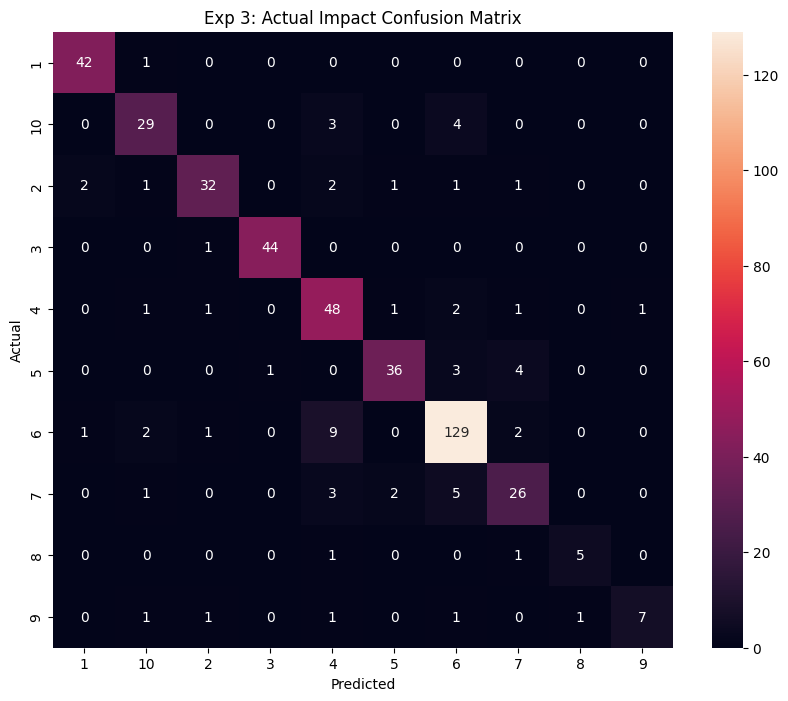

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os, shutil

# --- [4. FINAL RESEARCH COMPARISON] ---
# EXP 2: Synthetic Only
model_exp2 = BaselineCNN().to(device); opt_s = optim.Adam(model_exp2.parameters(), lr=0.001)
synth_loader = DataLoader(datasets.ImageFolder(add_path, transform=transform), batch_size=32, shuffle=True)

print("Training EXP 2: Synthetic Only...")
for epoch in range(10):
    for imgs, lbls in synth_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt_s.zero_grad(); criterion(model_exp2(imgs), lbls).backward(); opt_s.step()

# EXP 3: Augmented
aug_path = "/content/gc10_augmented"
if not os.path.exists(aug_path):
    shutil.copytree(local_path, aug_path)

for f in ['8', '9']:
    src_dir = os.path.join(add_path, f)
    for file in os.listdir(src_dir):
        shutil.copy(os.path.join(src_dir, file), os.path.join(aug_path, f, file))

model_exp3 = BaselineCNN().to(device); opt_a = optim.Adam(model_exp3.parameters(), lr=0.001)
aug_loader = DataLoader(datasets.ImageFolder(aug_path, transform=transform, is_valid_file=is_valid_img), batch_size=32, shuffle=True)

print("Training EXP 3: Augmented...")
for epoch in range(10):
    for imgs, lbls in aug_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt_a.zero_grad(); criterion(model_exp3(imgs), lbls).backward(); opt_a.step()

# IMPACT REPORT
model_exp3.eval(); y_t3, y_p3 = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        _, p = torch.max(model_exp3(imgs), 1)
        y_t3.extend(lbls.cpu().numpy()); y_p3.extend(p.cpu().numpy())

print("\n--- FINAL RESEARCH IMPACT REPORT ---")
print(classification_report(y_t3, y_p3, target_names=full_dataset.classes))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_t3, y_p3), annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title("Exp 3: Actual Impact Confusion Matrix")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('final_impact.png')

In [ ]:
import shutil
# Zip the synthetic data
shutil.make_archive("/content/synthetic_data_final", 'zip', "/content/additional_data")
# Move to Drive
shutil.move("/content/synthetic_data_final.zip", "/content/drive/MyDrive/Colab Notebooks/dataset/synthetic_data_final.zip")
print("Augmented data successfully archived to Drive.")

Augmented data successfully archived to Drive.


In [ ]:
# --- [EXP 1: BASELINE] ---
model_exp1 = BaselineCNN().to(device)
optimizer = optim.Adam(model_exp1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training Experiment 1: Baseline (Real Data)...")
for epoch in range(10):
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(); criterion(model_exp1(imgs), lbls).backward(); optimizer.step()

# Show Result
run_experiment_report(model_exp1, test_loader, "EXP 1: BASELINE REPORT", full_dataset.classes)

Training Experiment 1: Baseline (Real Data)...

EXP 1: BASELINE REPORT
              precision    recall  f1-score   support

           1       0.71      0.84      0.77        43
          10       0.56      0.56      0.56        36
           2       0.50      0.38      0.43        40
           3       0.66      0.69      0.67        45
           4       0.77      0.78      0.77        55
           5       0.83      0.55      0.66        44
           6       0.72      0.80      0.76       144
           7       0.40      0.51      0.45        37
           8       0.00      0.00      0.00         7
           9       0.50      0.17      0.25        12

    accuracy                           0.66       463
   macro avg       0.56      0.53      0.53       463
weighted avg       0.65      0.66      0.65       463



([np.int64(9),
  np.int64(5),
  np.int64(4),
  np.int64(6),
  np.int64(6),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(7),
  np.int64(8),
  np.int64(6),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(4),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(5),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(6),
  np.int64(6),
  np.int64(2),
  np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(4),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(6),
  np.int64(6),
  np.int64(9),
  np.int64(1),
  np.int64(6),
  np.int64(2),
  np.int64(3),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(4),
  np.int64(6),
  np.int64(3),
  np.int64(7),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64

In [ ]:
# --- [EXP 2: SYNTHETIC DATA ONLY] ---
# Note: Ensure you have already run the CGAN and generated 'additional_data'
synth_dataset = datasets.ImageFolder(root=add_path, transform=transform)
synth_loader = DataLoader(synth_dataset, batch_size=32, shuffle=True)

model_exp2 = BaselineCNN().to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)

print("Training Experiment 2: Synthetic Data Only...")
for epoch in range(10):
    for imgs, lbls in synth_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_exp2.zero_grad(); criterion(model_exp2(imgs), lbls).backward(); optimizer_exp2.step()

# Show Result (Always testing on the REAL test_loader)
run_experiment_report(model_exp2, test_loader, "EXP 2: SYNTHETIC ONLY REPORT", full_dataset.classes)

Training Experiment 2: Synthetic Data Only...

EXP 2: SYNTHETIC ONLY REPORT
              precision    recall  f1-score   support

           1       0.08      0.37      0.13        43
          10       0.09      0.67      0.16        36
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00        45
           4       0.00      0.00      0.00        55
           5       0.00      0.00      0.00        44
           6       0.00      0.00      0.00       144
           7       0.00      0.00      0.00        37
           8       0.00      0.00      0.00         7
           9       0.00      0.00      0.00        12

    accuracy                           0.09       463
   macro avg       0.02      0.10      0.03       463
weighted avg       0.01      0.09      0.02       463



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


([np.int64(9),
  np.int64(5),
  np.int64(4),
  np.int64(6),
  np.int64(6),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(7),
  np.int64(8),
  np.int64(6),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(4),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64(5),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(6),
  np.int64(6),
  np.int64(2),
  np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(4),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(6),
  np.int64(6),
  np.int64(9),
  np.int64(1),
  np.int64(6),
  np.int64(2),
  np.int64(3),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(4),
  np.int64(6),
  np.int64(3),
  np.int64(7),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(6),
  np.int64

Training Experiment 3: Augmented (Real + Synthetic)...

EXP 3: AUGMENTED IMPACT REPORT
              precision    recall  f1-score   support

           1       0.95      0.93      0.94        43
          10       0.67      0.86      0.76        36
           2       0.72      0.90      0.80        40
           3       1.00      0.96      0.98        45
           4       0.88      0.91      0.89        55
           5       0.94      0.75      0.84        44
           6       0.95      0.88      0.91       144
           7       0.67      0.70      0.68        37
           8       0.67      0.86      0.75         7
           9       0.78      0.58      0.67        12

    accuracy                           0.86       463
   macro avg       0.82      0.83      0.82       463
weighted avg       0.87      0.86      0.86       463



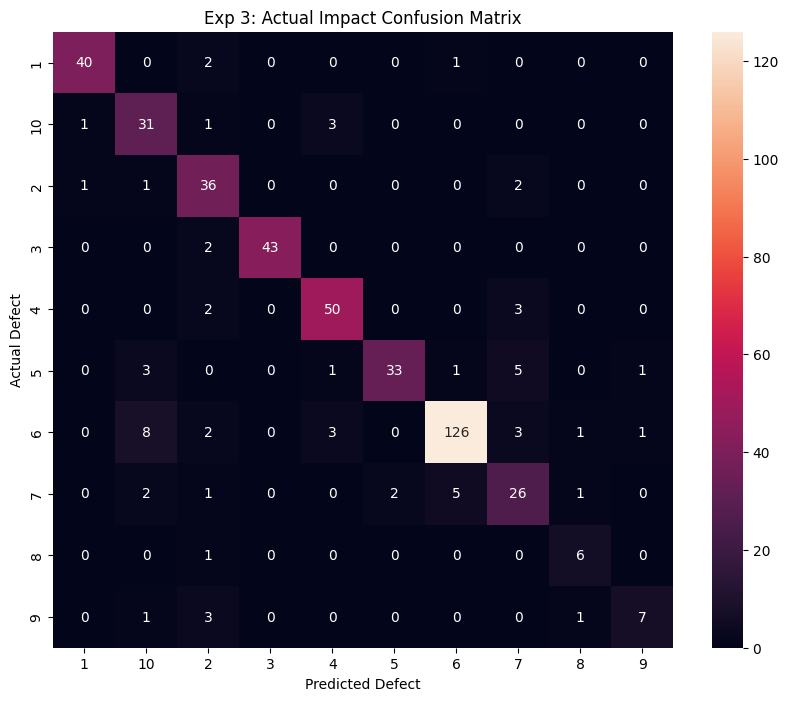

In [ ]:
# --- [EXP 3: AUGMENTED DATA] ---
# Combined dataset loader
aug_dataset = datasets.ImageFolder(root=aug_path, transform=transform, is_valid_file=is_valid_img)
aug_loader = DataLoader(aug_dataset, batch_size=32, shuffle=True)

model_exp3 = BaselineCNN().to(device)
optimizer_exp3 = optim.Adam(model_exp3.parameters(), lr=0.001)

print("Training Experiment 3: Augmented (Real + Synthetic)...")
for epoch in range(10):
    for imgs, lbls in aug_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_exp3.zero_grad(); criterion(model_exp3(imgs), lbls).backward(); optimizer_exp3.step()

# Show Final Impact Result
y_t, y_p = run_experiment_report(model_exp3, test_loader, "EXP 3: AUGMENTED IMPACT REPORT", full_dataset.classes)

# Final Visualization: Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_t, y_p), annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title("Exp 3: Actual Impact Confusion Matrix")
plt.ylabel('Actual Defect'); plt.xlabel('Predicted Defect')
plt.show()